# Tools
Durante este ejercicio se aprende el manejo básico de herramientas (tools)

# Steps
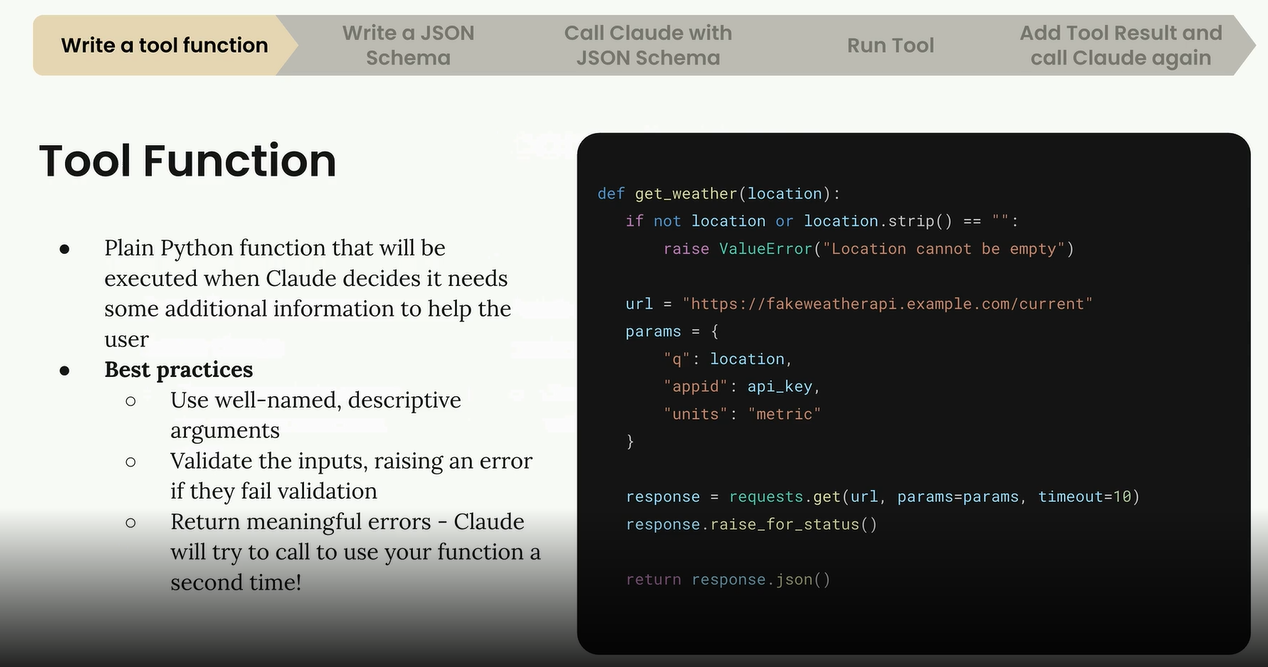

In [1]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [2]:
# Helper functions
from anthropic.types import Message

def add_user_message(messages, message):
    user_message = {
        "role": "user", 
        "content": message.content if isinstance(message, Message) else message
        }
    messages.append(user_message)

def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant", 
        "content": message.content if isinstance(message, Message) else message
        }
    messages.append(assistant_message)

def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message

def text_from_message(message):
    return "\n".join(
        # Extract text blocks from the message content
        [block.text for block in message.content if block.type == "text"]
        ) 

In [18]:
# Tools and Schemas

from datetime import datetime, timedelta
# función que define la duración de tiempo de una fecha dada a otra (ejemplo hoy dentro de 15 días)
def add_duration_to_datetime(datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")

# Función que define un recordatorio para una fecha dada (ejemplo recordatorio para hoy dentro de 15 días)
def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")

add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

Hay que hacer primero la función que requerimos y luego escribir el JSON que refleja la estructura de lo que requerimos.

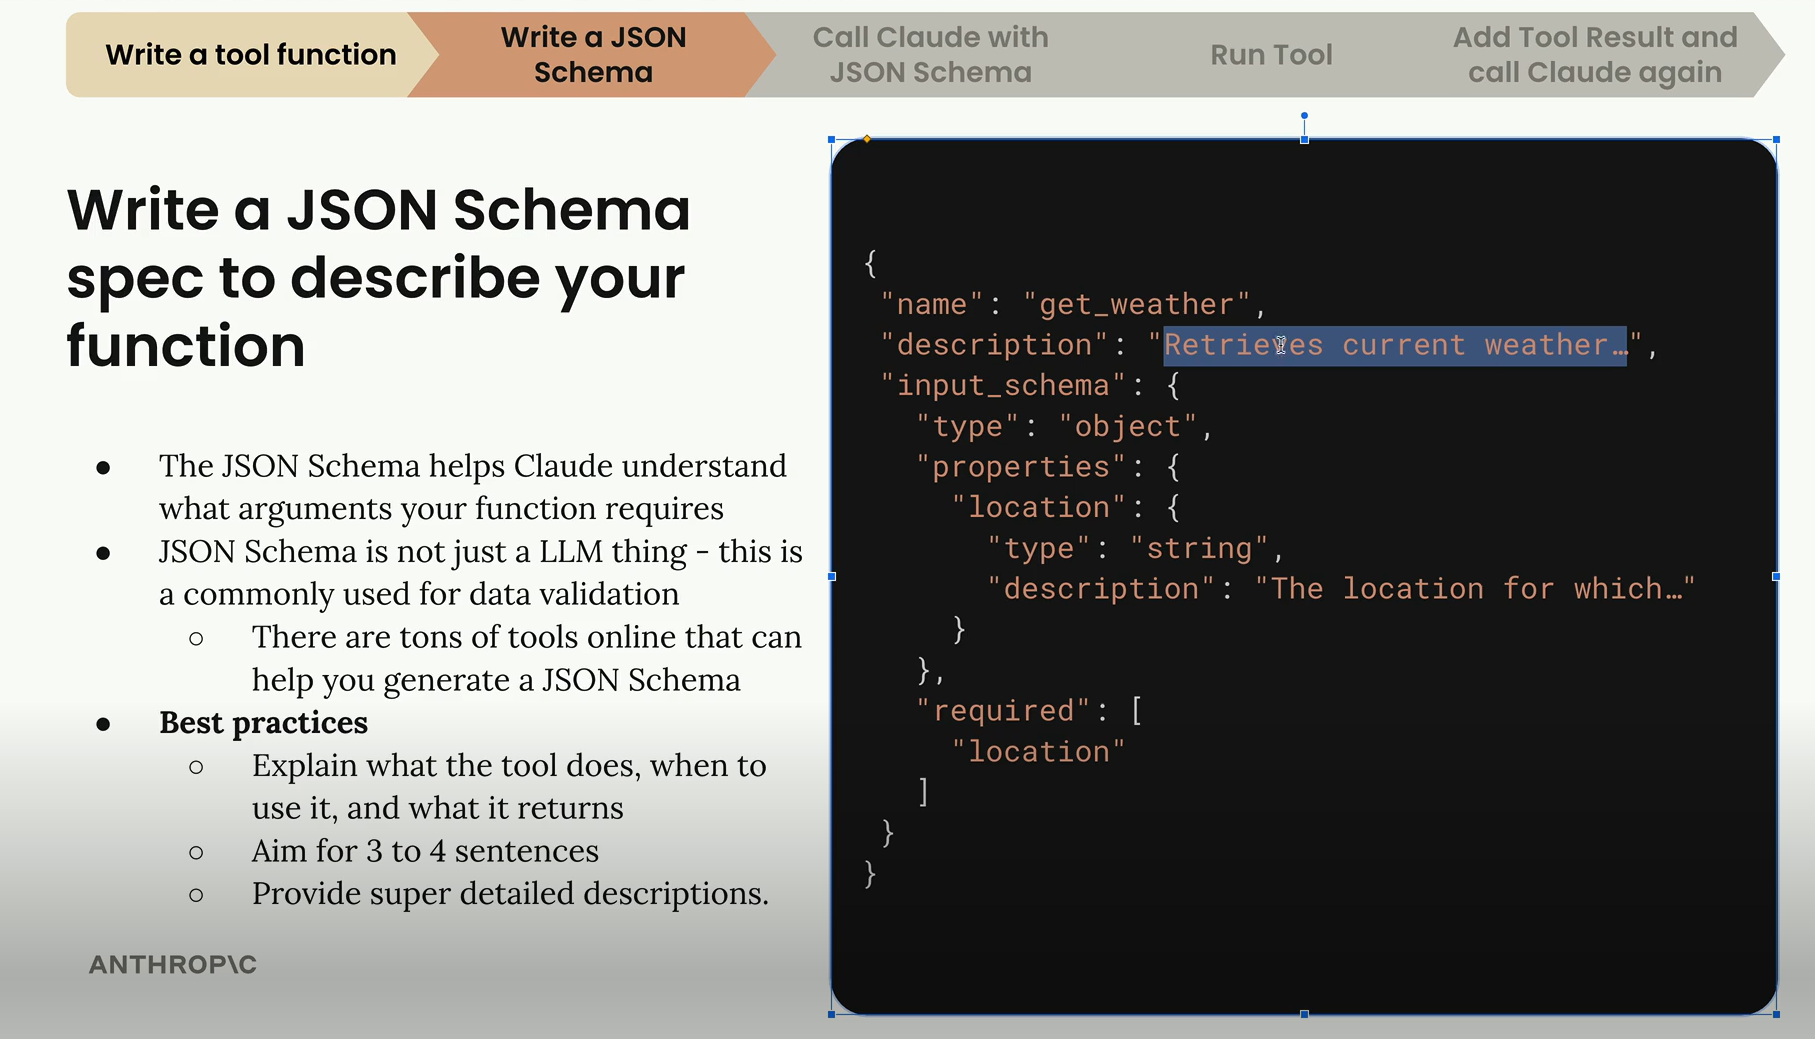

Para lograr crear un esquema correcto se utilza como buena práctica el usar un LLM al que le pasemos la función que hemos creado y el estandar (ejemplo el de Claude que se encuentra en su página oficial) y este nos genera el esquema que debemos utilizar:
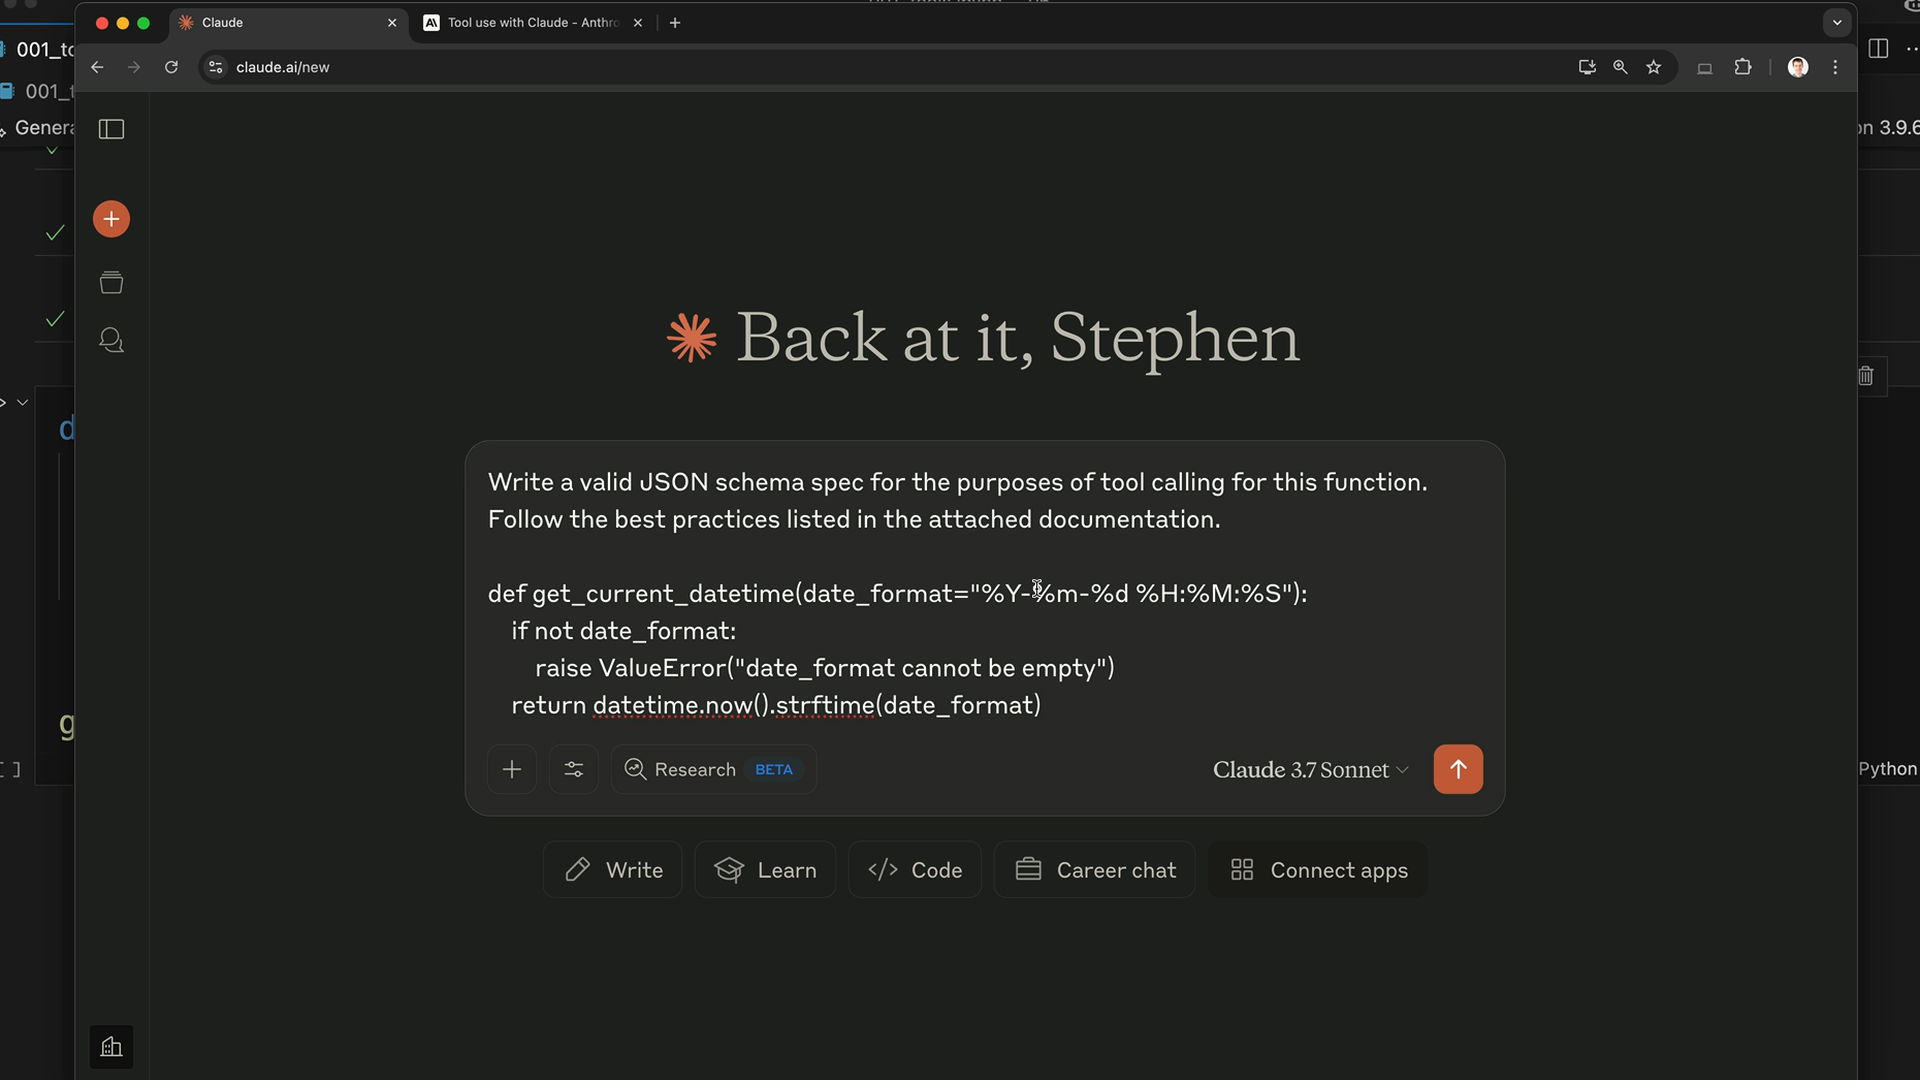

In [3]:
#get_current_datetime tool function and schema
from datetime import datetime
from anthropic.types import ToolParam

def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("date_format cannot be empty")
    return datetime.now().strftime(date_format)

get_current_datetime_schema = {
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A string specifying the format of the returned datetime. Uses Python's strftime format codes.",
                "default": "%Y-%m-%d %H:%M:%S"
            }
        },
        "required": []
    }
}

Ahora se debe interactuar con Claude utilizando el JSON:

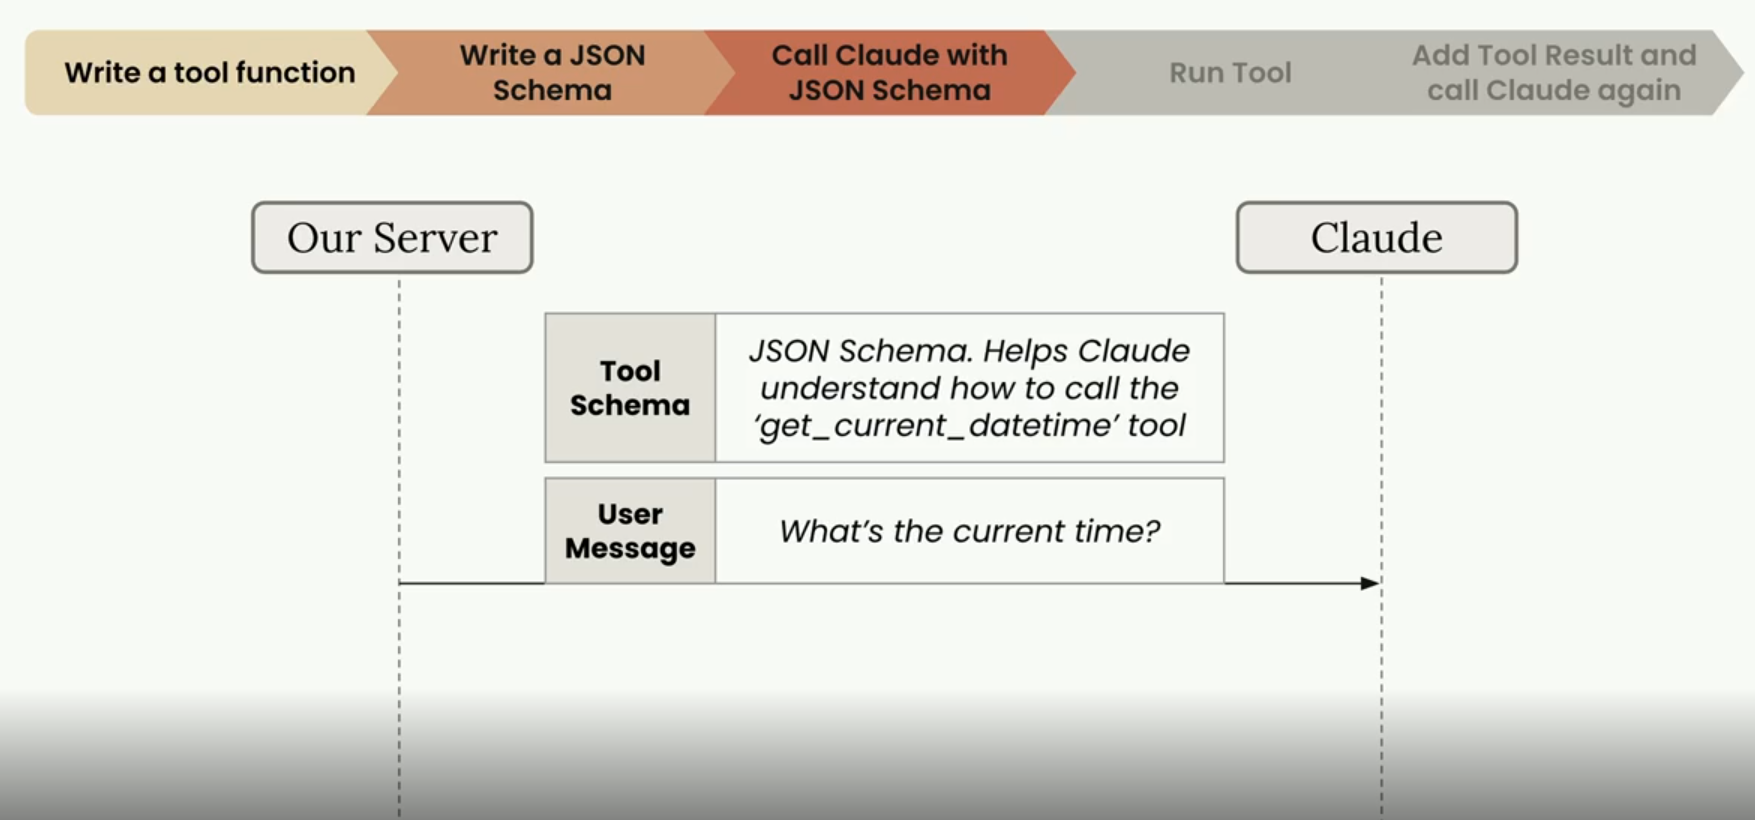

In [4]:
messages = []
messages.append(
    {
    "role": "user",
    "content": "What is the exact time, formatted as HH:MM:SS?"
    }
)

response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)

messages.append({
    "role": "assistant", 
    "content": response.content
})
messages

[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01VaAZvLSZfrXFVMhS2wvJ2L', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]}]

# Comprendiendo el resultado

El contenido de **messages** muestra un mensaje con el siguiente contenido:
[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS?'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01FzNECcouDtsFmLMaQsLzqG', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]
 }
]

De ese contenido el *ToolUseBlock* es clave para identificar la información necesaria, que en este caso es la hora específica de nuestro sistema con el formato **HH:MM:SS**. Esta información de la respuesta puede ser extraida directamente si consultamos *response.content[0]* para que nos muestre solo lo que nos interesa. El resultado sería:
ToolUseBlock(id='toolu_01FzNECcouDtsFmLMaQsLzqG', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')

Ahora si queremos usar esa información, podemos tomar la función get_current_datetime() y pasarle el formato de la respuesta que ya tenemos **response.content[0].input**. La siguiente función muestra como hacerlo

In [5]:
time= get_current_datetime(**response.content[0].input)

# Ahora vamos a proceder con el paso final

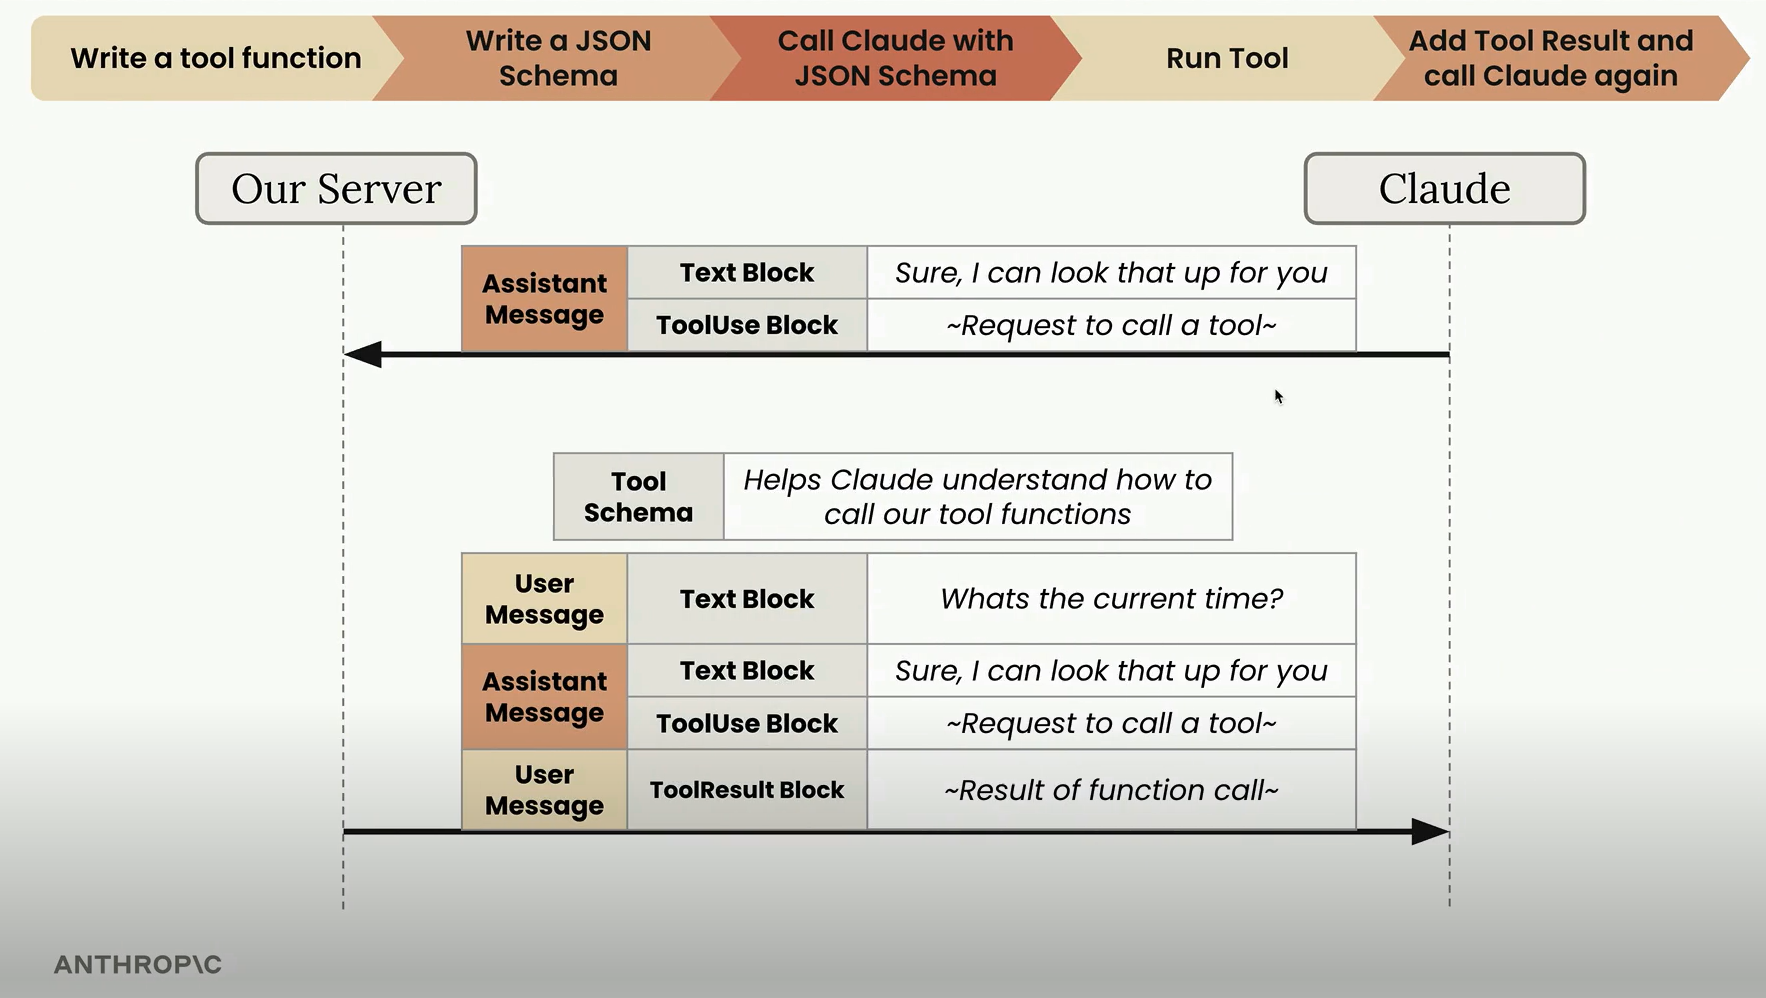

En este punto vamos a enviar una petición de claude con la toda la información requerida. Esto implica enviar todo el historial de conversación que contiene el mensaje original del usuario, el mensaje que hemos procedado del assistan con el toolUseBlock, y el mensaje final (user message), que contendrá un block nuevo llamado Tool Result Block. Este bloque permite comunicar los resultados de correr a tool function. 

# Nota
Es importante recordar que tool_used_id debe ser el mismo del ToolUseBlock. Ademáa, en content la salidad de haber ejecutado un tool debe ser seralizada como un string. is_error, debe ser marcado como True si llega a suceder un error.
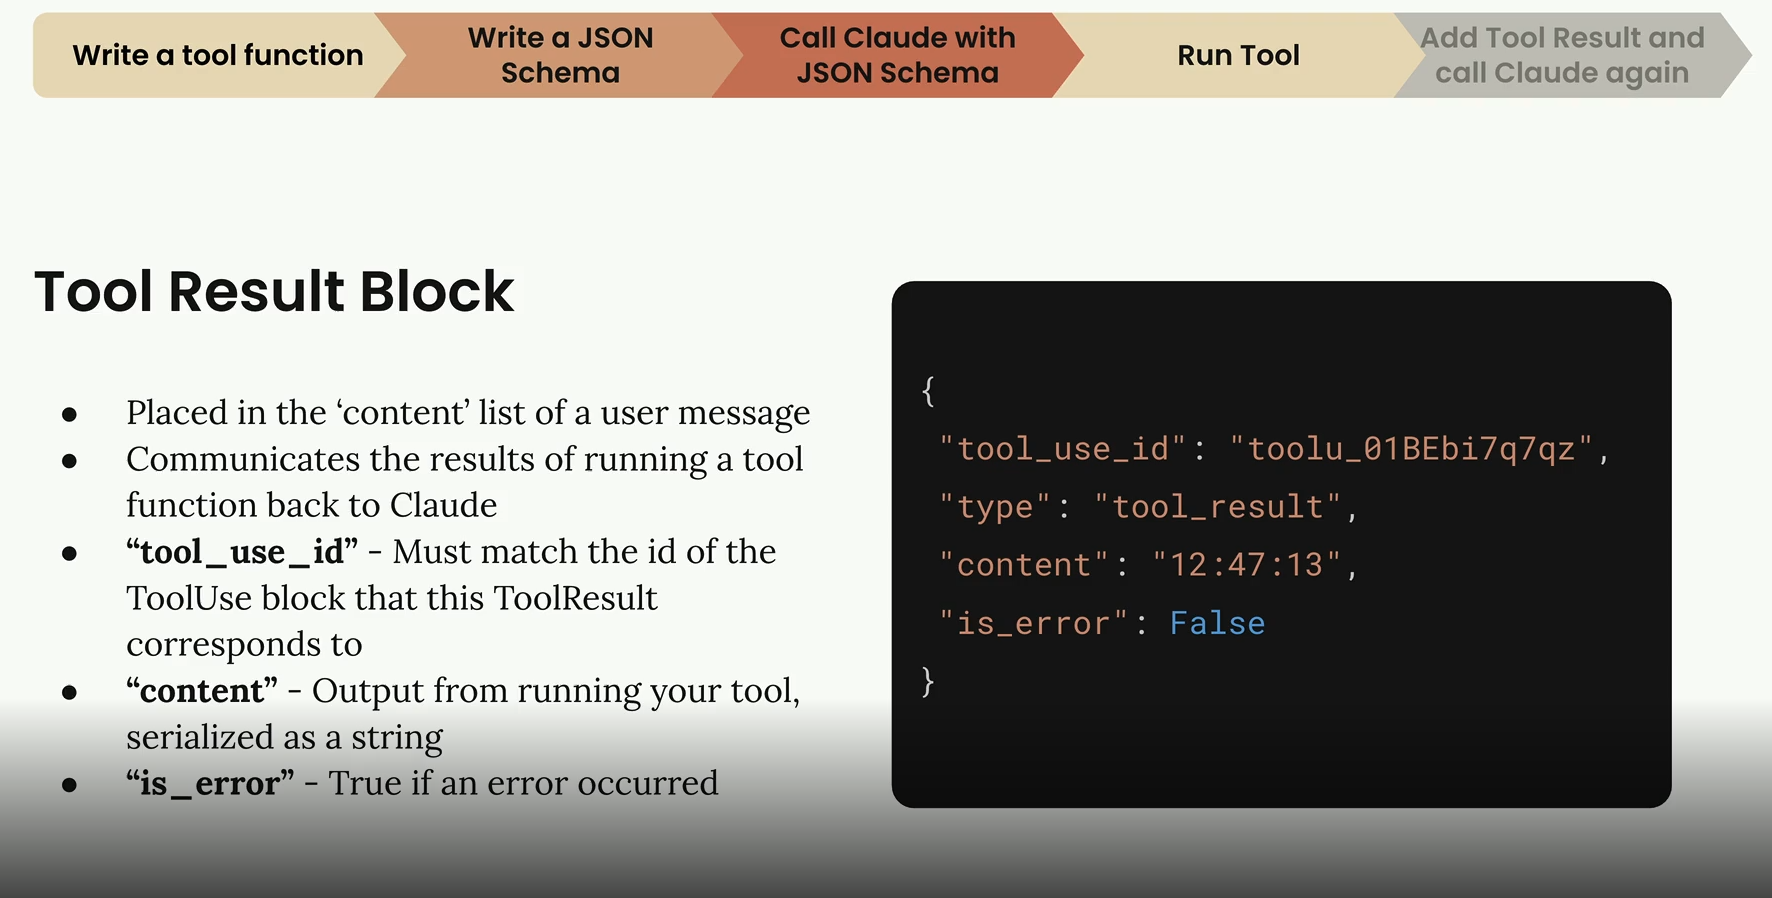

In [ ]:
messages.append({
    "role": "user", 
    "content": [
        {
            "type": "tool_result",
            "tool_use_id": response.content[0].id,
            "content": time,
            "is_error": False
        }
    ]
})
messages

In [ ]:
client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)

# Conversando con herramientas (Tool)

Recordemos que el objetivo es crear un recordatorio exactamente dentro de X tiempo, a la misma hora. Ejemplo crear un recordatorio de hoy en 15.

Ya tenemos todo el mensaje completo y se puede definir la respuesta que quiere el usuario. 
Primero obtuvimos la fecha y hora exacta para darsela a Claude. Luego, le agregamos la duración (dentro de 15 días) y finalmente crearemos el recordatorio.

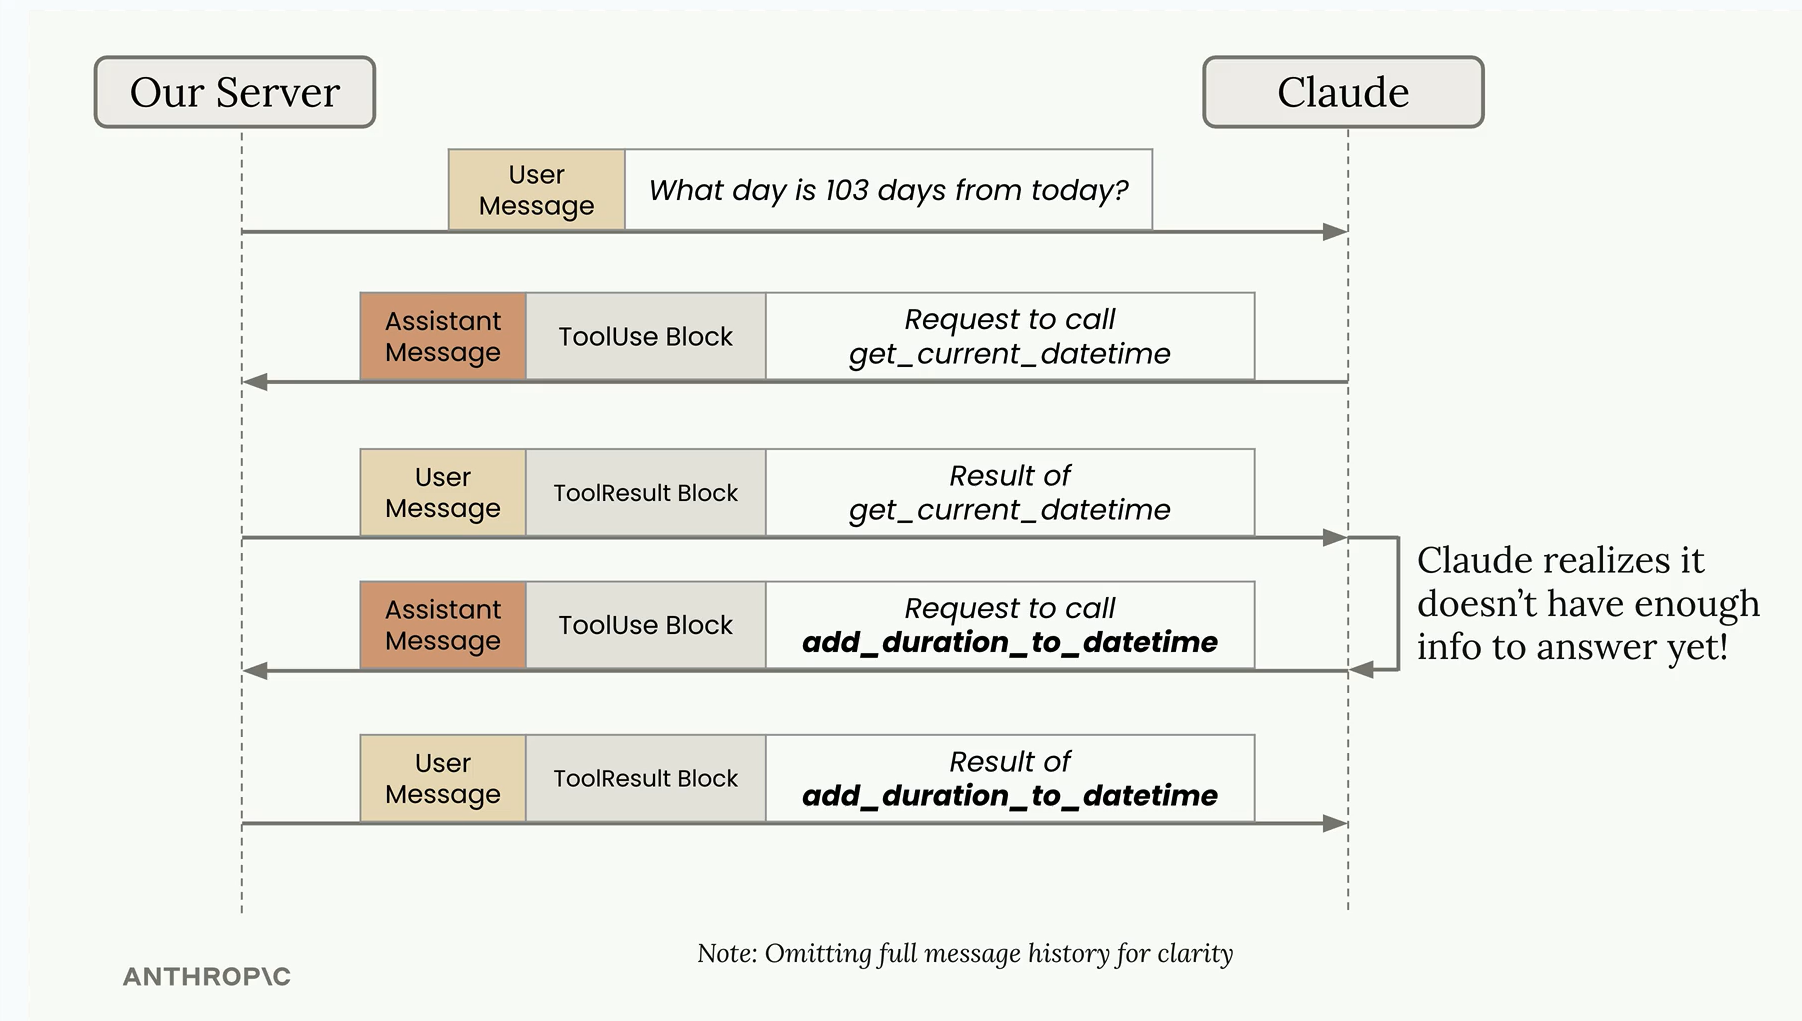

In [20]:
import json

def run_tool(tool_name, tool_input):
    if tool_name == "get_current_datetime":
        return get_current_datetime(**tool_input)
    elif tool_name == "add_duration_to_datetime":    
        return add_duration_to_datetime(**tool_input)
    elif tool_name == "set_reminder":
        return set_reminder(**tool_input)

def run_tools(message):
    tool_request= [
        block for block in message.content if block.type == "tool_use"
    ]
    tool_result_blocks = []

    for tool_use in tool_request:
        
        try:
            tool_output=run_tool(tool_use.name, tool_use.input)
            tool_result_block = {
                    "type": "tool_result",
                    "tool_use_id": tool_use.id,
                    "content": json.dumps(tool_output),
                    "is_error": False
            }
        except Exception as e:
                tool_result_block = {
                    "type": "tool_result",
                    "tool_use_id": tool_use.id,
                    "content": f"Error: {str(e)}",
                    "is_error": True
            }

        tool_result_blocks.append(tool_result_block)
                                          
    return tool_result_blocks
           
                

In [21]:
def run_conversation(messages):
    while True:
        response = chat(messages, tools=[
            get_current_datetime_schema,
            add_duration_to_datetime_schema,
            set_reminder_schema
            ])

        add_assistant_message(messages, response)
        print("Assistant response:", text_from_message(response))
        
        if response.stop_reason != "tool_use":
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)
        
    return messages

In [22]:
messages = []
add_user_message(
    messages, 
    "Set a reminder for my doctors apponintment. Its 177 days after Jan 1st, 2050"
    )
run_conversation(messages)

Assistant response: I'll help you set a reminder for your doctor's appointment. First, let me calculate what date is 177 days after January 1st, 2050.
Assistant response: Now I'll set a reminder for your doctor's appointment on June 27, 2050:
----
Setting the following reminder for 2050-06-27T00:00:00:
Doctor's appointment
----
Assistant response: Perfect! I've set a reminder for your doctor's appointment on **Monday, June 27, 2050** at 12:00 AM. You'll receive a notification at that time.


[{'role': 'user',
  'content': 'Set a reminder for my doctors apponintment. Its 177 days after Jan 1st, 2050'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll help you set a reminder for your doctor's appointment. First, let me calculate what date is 177 days after January 1st, 2050.", type='text'),
   ToolUseBlock(id='toolu_01B2aL9JLCvTkEd7e84PHuQi', caller=DirectCaller(type='direct'), input={'datetime_str': '2050-01-01', 'duration': 177, 'unit': 'days'}, name='add_duration_to_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01B2aL9JLCvTkEd7e84PHuQi',
    'content': '"Monday, June 27, 2050 12:00:00 AM"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Now I'll set a reminder for your doctor's appointment on June 27, 2050:", type='text'),
   ToolUseBlock(id='toolu_01HencYEzG5svYDEeMvnr4Se', caller=DirectCaller(type='direct'), input={'content': "Docto